<a href="https://colab.research.google.com/github/BERTHELEILA/Challenge-Alura-Store/blob/main/AluraStoreLatam_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [289]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56


#1. Análisis de facturación



####En este primer análisis, se calcula el ingreso total de cada tienda, sumando los valores de la columna "Precio", de cada conjunto de datos de la tienda, para estimar los ingresos.

In [290]:
#Se configura el formato de visualización de números en Pandas.
pd.options.display.float_format = '{:,.2f}'.format

In [291]:
#Se calculan ingresos por tienda.
ingreso_tienda = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

In [292]:
#Se crea un diccionario llamado datos_ingresos para almacenar los datos.
datos_ingresos = {
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingresos Totales": [ingreso_tienda, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
}

In [293]:
#Se convierte el diccionario en un DataFrame.
tabla_ingresos = pd.DataFrame(datos_ingresos)

In [294]:
#Se ordenan los ingresos de mayor a menor.
tabla_ingresos = tabla_ingresos.sort_values(by="Ingresos Totales", ascending=False)

In [295]:
#Resultado.
print("Ingresos totales por tienda (ordenados de mayor a menor):\n")
tabla_ingresos

Ingresos totales por tienda (ordenados de mayor a menor):



,Tienda,Ingresos Totales
0,Tienda 1,"1,150,880,400.00"
1,Tienda 2,"1,116,343,500.00"
2,Tienda 3,"1,098,019,600.00"
3,Tienda 4,"1,038,375,700.00"


# 2. Ventas por categoría

#####Se calcula la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [296]:
#Se calcula cantidad de ventas por categoría en cada tienda.
cat_tienda = tienda.groupby("Categoría del Producto").size()
cat_tienda2 = tienda2.groupby("Categoría del Producto").size()
cat_tienda3 = tienda3.groupby("Categoría del Producto").size()
cat_tienda4 = tienda4.groupby("Categoría del Producto").size()

In [297]:
#Se crea una tabla comparativa con las categorías de todas las tiendas.
tabla_categorias = pd.DataFrame({
    "Tienda 1": cat_tienda,
    "Tienda 2": cat_tienda2,
    "Tienda 3": cat_tienda3,
    "Tienda 4": cat_tienda4
})

In [298]:
#Se ordenan las categorías según el total de ventas.
tabla_categorias["Total"] = tabla_categorias.sum(axis=1)
tabla_categorias = tabla_categorias.sort_values(by="Total", ascending=False)

In [299]:
#Resultado.
print("Cantidad de productos vendidos por categoría en cada tienda:\n")
tabla_categorias

Cantidad de productos vendidos por categoría en cada tienda:



,Tienda 1,Tienda 2,Tienda 3,Tienda 4,Total
Categoría del Producto,,,,,
Muebles,465,442,499,480,1886
Electrónicos,448,422,451,451,1772
Juguetes,324,313,315,338,1290
Electrodomésticos,312,305,278,254,1149
Deportes y diversión,284,275,277,277,1113
Instrumentos musicales,182,224,177,170,753
Libros,173,197,185,187,742
Artículos para el hogar,171,181,177,201,730


# 3. Calificación promedio de la tienda


#####En este paso, se calculan las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [300]:
#Se calcula la calificación promedio de cada tienda.
prom_calif_tienda = tienda["Calificación"].mean()
prom_calif_tienda2 = tienda2["Calificación"].mean()
prom_calif_tienda3 = tienda3["Calificación"].mean()
prom_calif_tienda4 = tienda4["Calificación"].mean()


In [301]:
#Se crea diccionario con los promedios y se crea el Data Frame.
datos_calificaciones = {
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Calificación Promedio": [
        prom_calif_tienda,
        prom_calif_tienda2,
        prom_calif_tienda3,
        prom_calif_tienda4
    ]
}
tabla_calificaciones = pd.DataFrame(datos_calificaciones)

In [302]:
#Se ordena de mayor a menor calificación.
tabla_calificaciones = tabla_calificaciones.sort_values(
    by="Calificación Promedio",
    ascending=False
)

In [303]:
#Resultado.
print("Calificación promedio de clientes por tienda:\n")

tabla_calificaciones

Calificación promedio de clientes por tienda:



,Tienda,Calificación Promedio
2,Tienda 3,4.05
1,Tienda 2,4.04
3,Tienda 4,4.00
0,Tienda 1,3.98


# 4. Productos más y menos vendidos

#####Se identifican qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualizamos los resultados para que quede claro qué productos destacaron en ventas para cada tienda.

In [304]:
#Se crea diccionario, unificando tiendas.
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

In [305]:
#Se itera sobre cada tienda para contar las ventas por producto.
for nombre, datos in tiendas.items():
    ventas_producto = datos["Producto"].value_counts()
    #5 productos más vendidos
    top5 = ventas_producto.head(5).reset_index()
    top5.columns = ["Producto", "Cantidad de ventas"]
    #5 productos menos vendidos
    bottom5 = ventas_producto.tail(5).reset_index()
    bottom5.columns = ["Producto", "Cantidad de ventas"]
    print(f"\nResultados para {nombre}\n")
    print("Productos más vendidos:\n")
    display(top5)
    print("Productos menos vendidos:\n")
    display(bottom5)


Resultados para Tienda 1

Productos más vendidos:



,Producto,Cantidad de ventas
0,Microondas,60
1,TV LED UHD 4K,60
2,Armario,60
3,Secadora de ropa,58
4,Mesa de noche,56


Productos menos vendidos:



,Producto,Cantidad de ventas
0,Ciencia de datos con Python,39
1,Pandereta,36
2,Olla de presión,35
3,Auriculares con micrófono,33
4,Celular ABXY,33



Resultados para Tienda 2

Productos más vendidos:



...

,Producto,Cantidad de ventas
0,Guitarra eléctrica,38
1,Set de vasos,36
2,Mochila,36
3,Microondas,36
4,Bloques de construcción,35



Resultados para Tienda 4

Productos más vendidos:



,Producto,Cantidad de ventas
0,Cama box,62
1,Cubertería,59
2,Dashboards con Power BI,56
3,Cama king,56
4,Carrito de control remoto,55


Productos menos vendidos:



,Producto,Cantidad de ventas
0,Refrigerador,38
1,Ciencia de datos con Python,38
2,Guitarra acústica,37
3,Armario,34
4,Guitarra eléctrica,33


# 5. Envío promedio por tienda

#####Se calcula el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda, sabiendo que el cliente paga el envío.

In [306]:
#Costo de envío promedio por tienda
envio_tienda1 = tienda["Costo de envío"].mean()
envio_tienda2 = tienda2["Costo de envío"].mean()
envio_tienda3 = tienda3["Costo de envío"].mean()
envio_tienda4 = tienda4["Costo de envío"].mean()

In [307]:
#Creación de diccionario y Data Frame.
datos_envio = {
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Costo de envío promedio": [
        envio_tienda1,
        envio_tienda2,
        envio_tienda3,
        envio_tienda4
    ]
}
tabla_envios = pd.DataFrame(datos_envio)

In [308]:
#Costo de envío de menor a mayor.
tabla_envios = tabla_envios.sort_values(
by="Costo de envío promedio",
ascending=True
)

In [309]:
#Resultado.
print("Costo de envío promedio por tienda:\n")

tabla_envios

Costo de envío promedio por tienda:



,Tienda,Costo de envío promedio
3,Tienda 4,"23,459.46"
2,Tienda 3,"24,805.68"
1,Tienda 2,"25,216.24"
0,Tienda 1,"26,018.61"


# 7. Informe final

####**Introducción:**
El presente análisis tiene como objetivo evaluar el desempeño de las cuatro tiendas del Sr. Juan. Para ello se analizaron variables clave como los ingresos totales generados por cada tienda, las categorías de productos más y menos vendidas, la calificación promedio otorgada por los clientes, los productos con mayor y menor volumen de ventas y el costo promedio de envío.
A través de estos indicadores y de las visualizaciones generadas, se busca identificar patrones de comportamiento en las ventas y en la experiencia del cliente, con el fin de determinar cuál de las tiendas presenta el desempeño más débil y, por lo tanto, podría ser considerada para su venta.

#### **Desarrollo del análisis.**
En primer lugar, se analizaron los ingresos totales por tienda, lo que permitió identificar cuáles generan mayor facturación. Este indicador es clave para evaluar el rendimiento comercial general de cada tienda.


Visualización de los ingresos totales generados por cada tienda.

Este gráfico de barras permite comparar la facturación entre las distintas tiendas e identificar cuál presenta el mayor nivel de ingresos.



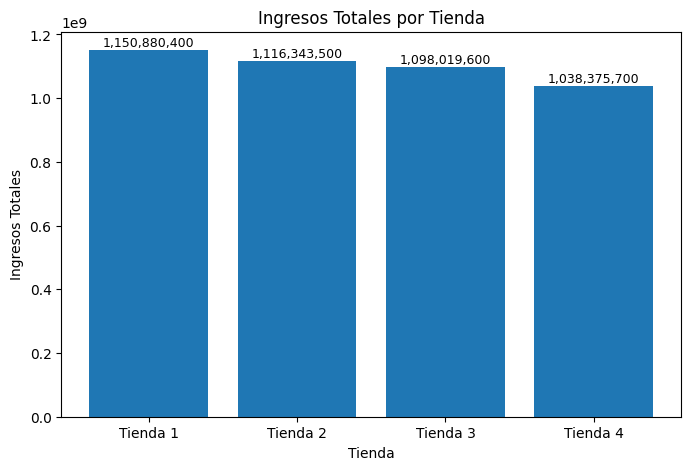

In [310]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(tabla_ingresos["Tienda"], tabla_ingresos["Ingresos Totales"])
plt.title("Ingresos Totales por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingresos Totales")
for i, v in enumerate(tabla_ingresos["Ingresos Totales"]):
    plt.text(i, v + 10000000, f"{v:,.0f}", ha='center', fontsize=9)
print("Visualización de los ingresos totales generados por cada tienda.\n")
print("Este gráfico de barras permite comparar la facturación entre las distintas tiendas e identificar cuál presenta el mayor nivel de ingresos.\n")
plt.show()

Posteriormente, se examinó la distribución de ventas por categoría de productos, lo que permitió comprender qué tipos de productos concentran la mayor demanda. Este análisis ayuda a identificar tendencias de consumo y posibles oportunidades o debilidades en la oferta de productos.

Visualización de la distribución de ventas por categoría de productos.

Este gráfico permite identificar qué categorías concentran la mayor cantidad de ventas y cuáles presentan menor demanda.



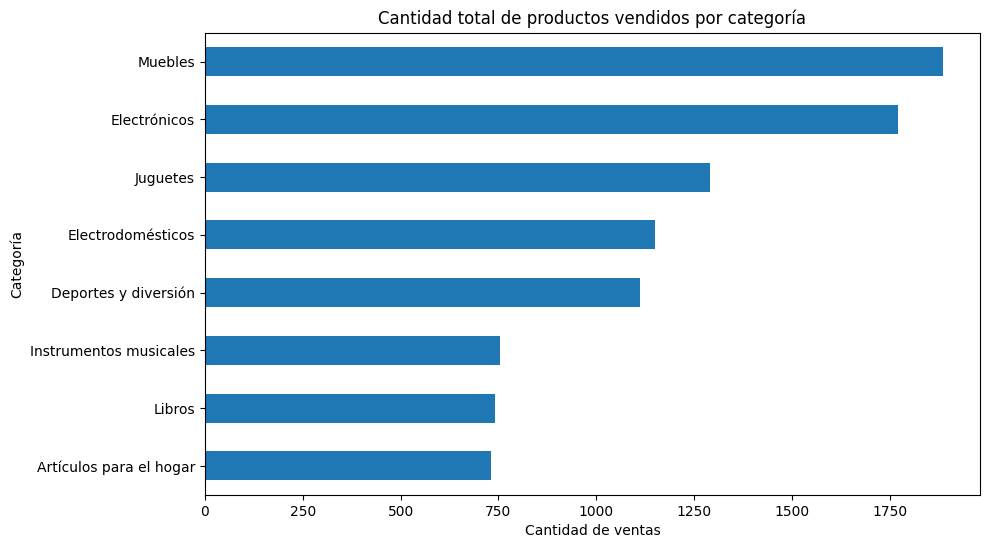

In [311]:
plt.figure(figsize=(10,6))
tabla_categorias["Total"].sort_values().plot(kind="barh")
plt.title("Cantidad total de productos vendidos por categoría")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Categoría")
print("Visualización de la distribución de ventas por categoría de productos.\n")
print("Este gráfico permite identificar qué categorías concentran la mayor cantidad de ventas y cuáles presentan menor demanda.\n")
plt.show()

También se analizaron las calificaciones promedio otorgadas por los clientes, un indicador fundamental para evaluar la satisfacción del cliente.
Adicionalmente, se identificaron los productos más vendidos y los menos vendidos en cada tienda, lo que permitió detectar cuáles artículos impulsan las ventas y cuáles presentan menor rotación.

Visualización de la calificación promedio de los clientes por tienda.

Este gráfico de líneas permite observar la variación en la satisfacción de los clientes entre las diferentes tiendas.



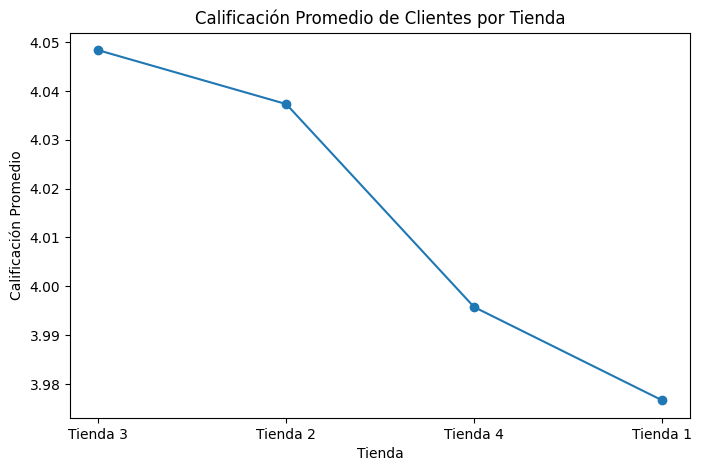

In [312]:
plt.figure(figsize=(8,5))
plt.plot(tabla_calificaciones["Tienda"], tabla_calificaciones["Calificación Promedio"], marker='o')
plt.title("Calificación Promedio de Clientes por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación Promedio")
print("Visualización de la calificación promedio de los clientes por tienda.\n")
print("Este gráfico de líneas permite observar la variación en la satisfacción de los clientes entre las diferentes tiendas.\n")
plt.show()

Finalmente, se evaluó el costo de envío promedio por tienda, un factor importante considerando que el cliente asume este costo.

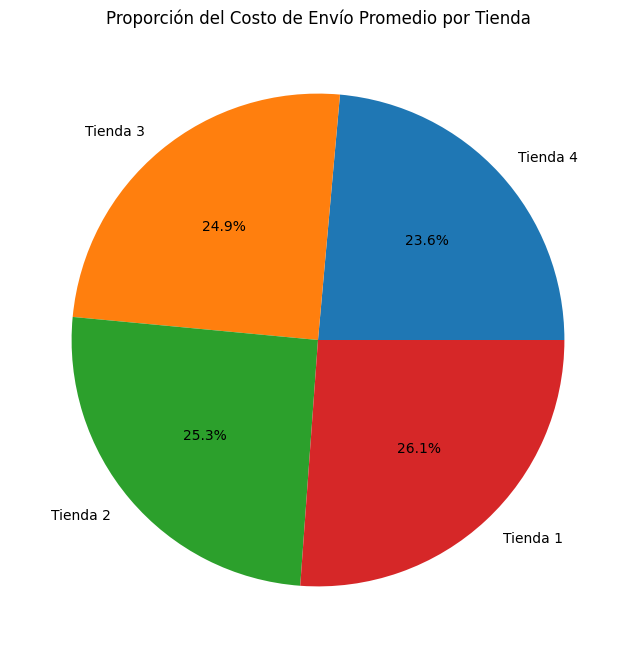

In [313]:
plt.figure(figsize=(8,8))
plt.pie(
    tabla_envios["Costo de envío promedio"],
    labels=tabla_envios["Tienda"],
    autopct='%1.1f%%'
)
plt.title("Proporción del Costo de Envío Promedio por Tienda")
plt.show()

**Las visualizaciones generadas facilitaron la interpretación de estos resultados, permitiendo comparar el desempeño de las tiendas y detectar diferencias en ingresos, popularidad de categorías, satisfacción del cliente y costos asociados a la compra.**

###**Conclusión.**
A partir de los resultados obtenidos, se observa que la Tienda 4 presenta el menor nivel de ingresos totales en comparación con las demás tiendas, lo que indica un desempeño comercial inferior. Aunque esta tienda muestra un costo de envío promedio más bajo y una calificación aceptable por parte de los clientes, su volumen de ventas es menor. Por esta razón, se recomienda que el Sr. Juan considere vender la Tienda 4, ya que representa la unidad con menor contribución al rendimiento global del negocio.